# 04 — Evaluation
WBC Classification · EfficientNetB3

**Run this notebook only after training is complete.**
The test set should be touched exactly once — here.

Outputs:
- Normalised confusion matrix
- Per-class precision / recall / F1
- Grad-CAM visualisations (3 samples per class)
- Misclassification analysis

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path

from dataset import build_dataset, CLASSES, NUM_CLASSES
from utils   import evaluate_model, plot_confusion_matrix, save_gradcam_grid

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR    = Path('../data/processed')
MODELS_DIR  = Path('../models/final')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 32

## Load Model

In [2]:
model_path = MODELS_DIR / 'efficientnetb3_wbc_final.keras'
model = tf.keras.models.load_model(model_path)
print(f'Model loaded from: {model_path}')
model.summary(line_length=80, expand_nested=False)

Model loaded from: ..\models\final\efficientnetb3_wbc_final.keras
Model: "EfficientNetB3_WBC"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 input_image (InputLayer)           [(None, 300, 300, 3)]           0           
                                                                                
 efficientnetb3 (Functional)        (None, 10, 10, 1536)            10783535    
                                                                                
 gap (GlobalAveragePooling2D)       (None, 1536)                    0           
                                                                                
 bn_head (BatchNormalization)       (None, 1536)                    6144        
                                                                                
 dropout_1 (Dropout)                (None, 1536)                    0           
               

## Load Test Set (do not shuffle!)

In [3]:
test_ds = build_dataset(
    DATA_DIR / 'test',
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False,   # Must be False for y_true to align with y_pred
    cache=False,     # Safe to keep False for test — only run once
)

[dataset] test: 3212 images across 9 classes


## Full Evaluation (confusion matrix + classification report)

                     precision    recall  f1-score   support

          Basophile     0.9903    0.9951    0.9927       206
        Eosinophile     0.8852    0.9069    0.8959       204
        Lymphoblast     0.9389    0.9902    0.9639       512
         Lymphocyte     0.9604    0.9541    0.9572       610
           Monocyte     0.9644    0.9289    0.9463       408
         Myeloblast     0.9833    0.9291    0.9555       508
   Neutrophile_Band     0.3864    0.8095    0.5231        21
Neutrophile_Segment     0.9742    0.9423    0.9580       641
         Normoblast     0.8584    0.9510    0.9023       102

           accuracy                         0.9489      3212
          macro avg     0.8824    0.9341    0.8994      3212
       weighted avg     0.9540    0.9489    0.9506      3212

[utils] Report saved → ..\results\classification_report.csv
[utils] Confusion matrix saved → ..\results\confusion_matrix.png


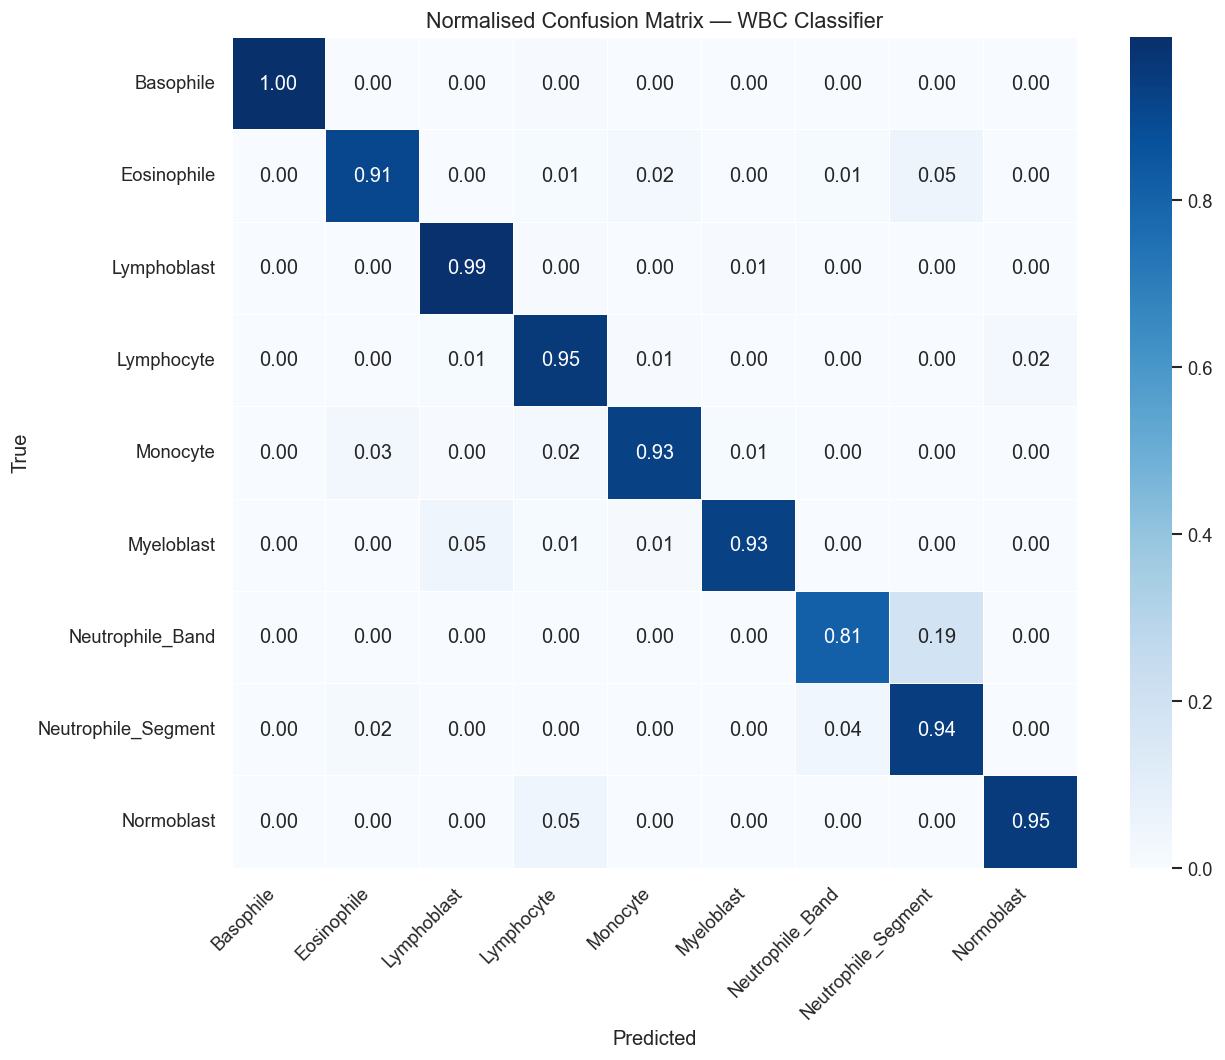

In [4]:
y_true, y_pred = evaluate_model(model, test_ds, save_dir=RESULTS_DIR)

## Misclassification Analysis
Which pairs of classes confuse the model most?

In [5]:
from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(y_true, y_pred)

# Off-diagonal entries sorted by frequency
errors = []
for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
    if i != j and cm[i, j] > 0:
        errors.append({
            'true':      CLASSES[i],
            'predicted': CLASSES[j],
            'count':     cm[i, j],
            'pct_of_true': cm[i, j] / cm[i].sum(),
        })

errors_df = pd.DataFrame(errors).sort_values('count', ascending=False)
print('Top misclassifications:')
display(errors_df.head(15))

Top misclassifications:


,true,predicted,count,pct_of_true
21,Myeloblast,Lymphoblast,24,0.047244
28,Neutrophile_Segment,Neutrophile_Band,23,0.035881
12,Lymphocyte,Normoblast,14,0.022951
26,Neutrophile_Segment,Eosinophile,12,0.018721
13,Monocyte,Eosinophile,12,0.029412
4,Eosinophile,Neutrophile_Segment,11,0.053922
15,Monocyte,Lymphocyte,8,0.019608
8,Lymphocyte,Lymphoblast,7,0.011475
23,Myeloblast,Monocyte,6,0.011811
29,Normoblast,Lymphocyte,5,0.049020


## Per-Class Metrics Bar Chart

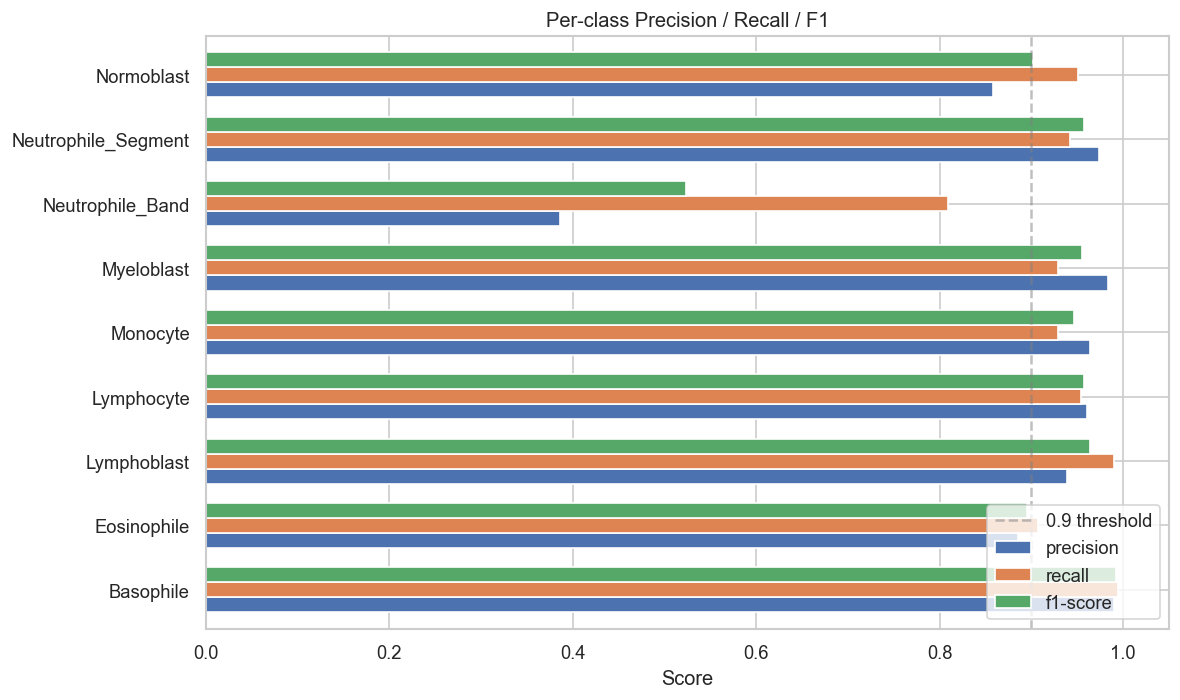

In [6]:
report_path = RESULTS_DIR / 'classification_report.csv'
report_df   = pd.read_csv(report_path, index_col=0)

# Extract per-class rows only
per_class = report_df.loc[CLASSES, ['precision', 'recall', 'f1-score']]

ax = per_class.plot(kind='barh', figsize=(10, 6), width=0.7)
ax.set_xlabel('Score')
ax.set_title('Per-class Precision / Recall / F1', fontsize=12)
ax.set_xlim(0, 1.05)
ax.axvline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_metrics.png', bbox_inches='tight')
plt.show()

## Summary

In [7]:
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)

macro_f1 = report_df.loc['macro avg', 'f1-score']
weighted_f1 = report_df.loc['weighted avg', 'f1-score']

print('=' * 45)
print('  Final Test Set Results')
print('=' * 45)
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  AUC          : {test_auc:.4f}')
print(f'  Macro F1     : {macro_f1:.4f}')
print(f'  Weighted F1  : {weighted_f1:.4f}')
print(f'  Loss         : {test_loss:.4f}')
print('=' * 45)

  Final Test Set Results
  Accuracy     : 0.9489
  AUC          : 0.9979
  Macro F1     : 0.8994
  Weighted F1  : 0.9506
  Loss         : 0.2437
